In [ ]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import nltk

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Load the dataset
news_dataset = pd.read_csv('/content/sample_data/train.csv')
news_dataset.fillna('', inplace=True)
news_dataset['content'] = news_dataset['author'] + ' ' + news_dataset['title']

In [ ]:
# Separating features and labels
X = news_dataset['content']
Y = news_dataset['label']

In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def preprocess_text(content):
    content = re.sub(r'http\S+|www\S+|https\S+', '', content, flags=re.MULTILINE)
    content = re.sub(r'@\w+', '', content)
    content = re.sub('[^a-zA-Z]', ' ', content)
    content = content.lower().split()
    content = [lemmatizer.lemmatize(word) for word in content if word not in stopwords.words('english')]
    return ' '.join(content)

news_dataset['content'] = news_dataset['content'].apply(preprocess_text)

KeyboardInterrupt: 

In [ ]:
# Apply lemmatization
data['content'] = data['content'].apply(lemmatize_text)

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
data = pd.read_csv('/content/sample_data/train.csv')  # Replace with the correct dataset path
data.fillna('', inplace=True)

# Combine author and title columns
data['content'] = data['author'] + ' ' + data['title']

# Lemmatization function
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower().split()
    return ' '.join([lemmatizer.lemmatize(word) for word in text if word not in stopwords.words('english')])

# Apply lemmatization
data['content'] = data['content'].apply(lemmatize_text)

# Feature extraction with TF-IDF
X = data['content']
y = data['label']
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Passive-Aggressive Classifier
pa_clf = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pa_clf.fit(X_train, y_train)

# Predictions and performance evaluation
y_pred = pa_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Accuracy: 0.9899038461538462

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Best Parameters: {'C': 0.1, 'early_stopping': False, 'max_iter': 500}
Accuracy: 0.9908653846153846

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



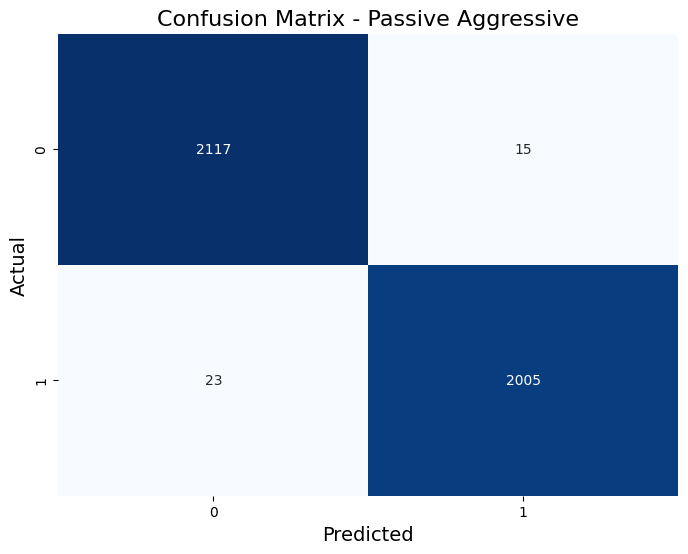

Classification Report - Passive Aggressive
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160

------------------------------------------------------------


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
data = pd.read_csv('/content/sample_data/train.csv')  # Replace with the correct path
data.fillna('', inplace=True)

# Combine author and title
data['content'] = data['author'] + ' ' + data['title']

# Lemmatization function
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower().split()
    return ' '.join([lemmatizer.lemmatize(word) for word in text if word not in stopwords.words('english')])

# Apply lemmatization
data['content'] = data['content'].apply(lemmatize_text)

# Feature extraction with TF-IDF
X = data['content']
y = data['label']
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
pa_clf = PassiveAggressiveClassifier()

# Set hyperparameter grid
param_grid = {
    'max_iter': [500, 1000, 2000],
    'C': [0.01, 0.1, 1.0, 10],
    'early_stopping': [True, False]
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(pa_clf, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_pa_clf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test data
y_pred = best_pa_clf.predict(X_test)
y_scores_passive = best_pa_clf.decision_function(X_test)
y_prob_passive = 1 / (1 + np.exp(-y_scores_passive))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

visualize_passive_aggressive(best_pa_clf, X_test, y_test)

fpr_passive, tpr_passive, _ = roc_curve(y_test, y_prob_passive)
roc_auc_passive = auc(fpr_passive, tpr_passive)

Best Parameters: {'C': 0.1, 'early_stopping': False, 'max_iter': 2000}
Accuracy: 0.9889423076923077

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



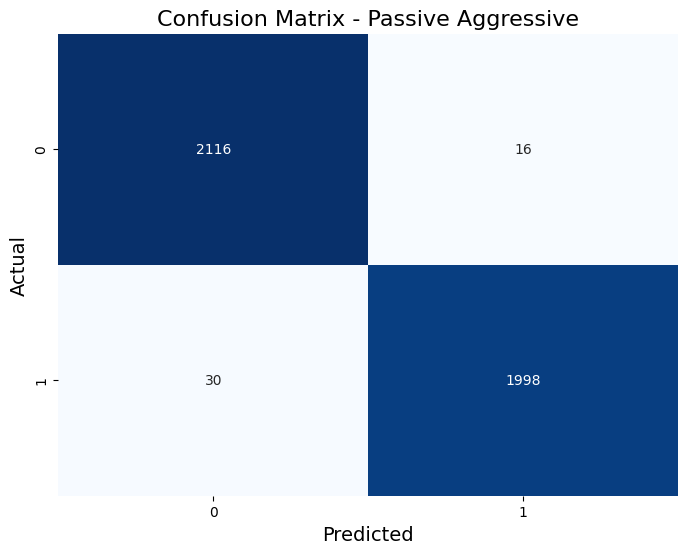

Classification Report - Passive Aggressive
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160

------------------------------------------------------------


In [ ]:
from nltk.stem import PorterStemmer

# Initialize Porter Stemmer
stemmer = PorterStemmer()

# Stemming function
def stem_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower().split()
    return ' '.join([stemmer.stem(word) for word in text if word not in stopwords.words('english')])

# Apply stemming
data['content'] = data['content'].apply(stem_text)

# Feature extraction with TF-IDF
X = data['content']
y = data['label']
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
pa_clf = PassiveAggressiveClassifier()

# Set hyperparameter grid
param_grid = {
    'max_iter': [500, 1000, 2000],
    'C': [0.01, 0.1, 1.0, 10],
    'early_stopping': [True, False]
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(pa_clf, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_pa_clf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test data
y_pred = best_pa_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

visualize_passive_aggressive(best_pa_clf, X_test, y_test)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Best Parameters for Naive Bayes: {'alpha': 1.0}
Accuracy (Naive Bayes): 0.9572115384615385

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      2132
           1       0.99      0.92      0.95      2028

    accuracy                           0.96      4160
   macro avg       0.96      0.96      0.96      4160
weighted avg       0.96      0.96      0.96      4160



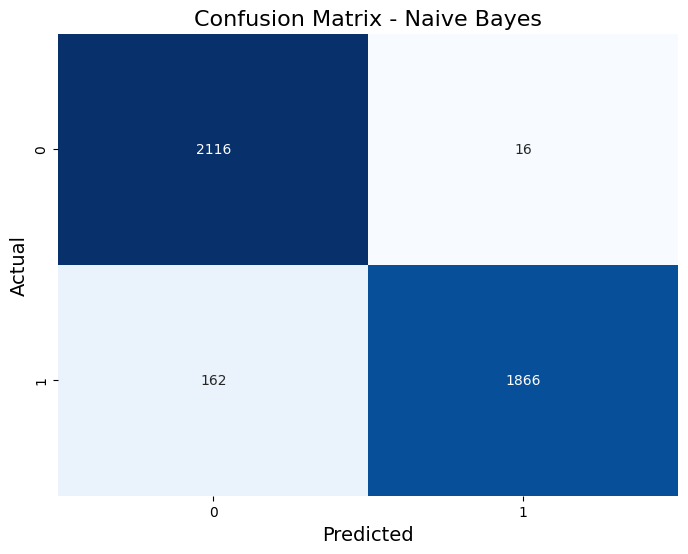

Classification Report - Naive Bayes
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2132
           1       0.99      0.92      0.95      2028

    accuracy                           0.96      4160
   macro avg       0.96      0.96      0.96      4160
weighted avg       0.96      0.96      0.96      4160

------------------------------------------------------------


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
data = pd.read_csv('/content/sample_data/train.csv')  # Replace with the correct path
data.fillna('', inplace=True)

# Combine author and title
data['content'] = data['author'] + ' ' + data['title']

# Text Preprocessing: Lemmatization
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower().split()
    text = ' '.join([lemmatizer.lemmatize(word) for word in text if word not in stopwords.words('english')])
    return text

data['content'] = data['content'].apply(preprocess_text)

# Feature Extraction with TF-IDF
X = data['content']
y = data['label']
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Naive Bayes model
nb_clf = MultinomialNB()

# Set hyperparameter grid for tuning
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5]  # Smoothing parameter
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(nb_clf, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_nb_clf = grid_search.best_estimator_
print("Best Parameters for Naive Bayes:", grid_search.best_params_)

# Evaluate on test data
y_pred = best_nb_clf.predict(X_test)
y_prob_nb = best_nb_clf.predict_proba(X_test)[:, 1]
print("Accuracy (Naive Bayes):", accuracy_score(y_test, y_pred))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred))

visualize_naive_bayes(best_nb_clf, X_test, y_test)

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Best Parameters for Naive Bayes: {'alpha': 1.5}
Accuracy (Naive Bayes): 0.9526442307692308

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.92      0.99      0.96      2132
           1       0.99      0.91      0.95      2028

    accuracy                           0.95      4160
   macro avg       0.96      0.95      0.95      4160
weighted avg       0.96      0.95      0.95      4160



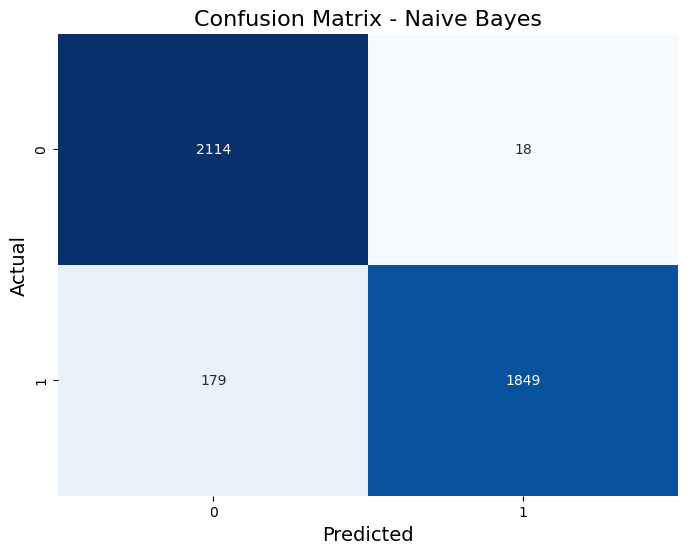

Classification Report - Naive Bayes
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      2132
           1       0.99      0.91      0.95      2028

    accuracy                           0.95      4160
   macro avg       0.96      0.95      0.95      4160
weighted avg       0.96      0.95      0.95      4160

------------------------------------------------------------


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

# Download necessary NLTK resources
nltk.download('stopwords')

# Load dataset
data = pd.read_csv('/content/sample_data/train.csv')  # Replace with the correct path
data.fillna('', inplace=True)

# Combine author and title
data['content'] = data['author'] + ' ' + data['title']

# Text Preprocessing: Stemming
stemmer = PorterStemmer()
def preprocess_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower().split()
    text = ' '.join([stemmer.stem(word) for word in text if word not in stopwords.words('english')])
    return text

data['content'] = data['content'].apply(preprocess_text)

# Feature Extraction with TF-IDF
X = data['content']
y = data['label']
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Naive Bayes model
nb_clf = MultinomialNB()

# Set hyperparameter grid for tuning
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5]  # Smoothing parameter
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(nb_clf, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_nb_clf = grid_search.best_estimator_
print("Best Parameters for Naive Bayes:", grid_search.best_params_)

# Evaluate on test data
y_pred = best_nb_clf.predict(X_test)
print("Accuracy (Naive Bayes):", accuracy_score(y_test, y_pred))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred))

visualize_naive_bayes(best_nb_clf, X_test, y_test)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Best Parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (SVM): 0.9901442307692307

Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



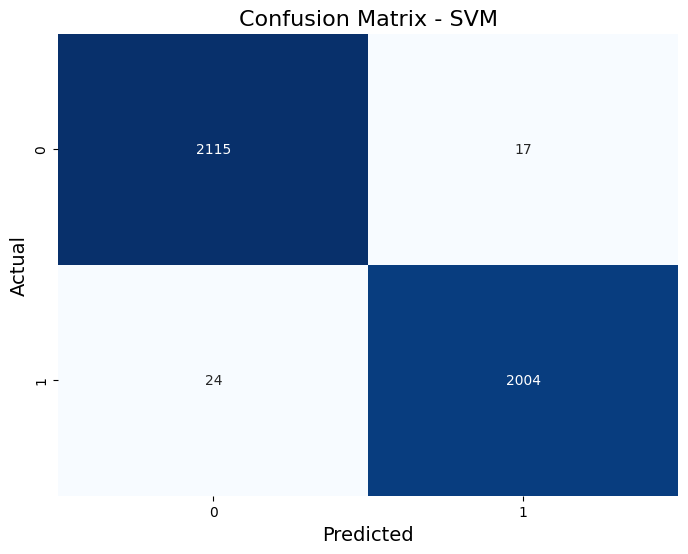

Classification Report - SVM
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160

------------------------------------------------------------


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

# Download necessary NLTK resources
nltk.download('stopwords')

# Load dataset
data = pd.read_csv('/content/sample_data/train.csv')  # Replace with the correct path
data.fillna('', inplace=True)

# Combine author and title
data['content'] = data['author'] + ' ' + data['title']

# Text Preprocessing: Stemming
stemmer = PorterStemmer()
def preprocess_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower().split()
    text = ' '.join([stemmer.stem(word) for word in text if word not in stopwords.words('english')])
    return text

from sklearn.svm import SVC

# Text Preprocessing (same as above)
data['content'] = data['content'].apply(preprocess_text)

# Feature Extraction with TF-IDF (same as above)
X = data['content']
y = data['label']
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Train-Test Split (same as above)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the SVM model
svm_clf = SVC()

# Set hyperparameter grid for tuning
param_grid = {
    'C': [0.01, 0.1, 1.0, 10],
    'kernel': ['linear', 'rbf'],  # Kernel types
    'gamma': ['scale', 'auto']  # Kernel coefficient
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(svm_clf, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_svm_clf = grid_search.best_estimator_
print("Best Parameters for SVM:", grid_search.best_params_)

# Evaluate on test data
y_pred = best_svm_clf.predict(X_test)
print("Accuracy (SVM):", accuracy_score(y_test, y_pred))
print("\nClassification Report (SVM):\n", classification_report(y_test, y_pred))

visualize_svm(best_svm_clf, X_test, y_test)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Best Parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (SVM): 0.9896634615384615

Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



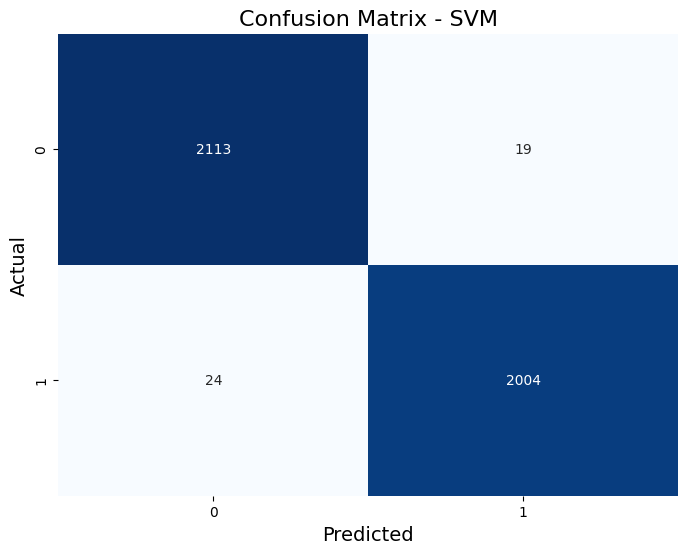

Classification Report - SVM
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2132
           1       0.99      0.99      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160

------------------------------------------------------------


In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc

# Download necessary NLTK resources
nltk.download('stopwords')

# Load dataset
data = pd.read_csv('/content/sample_data/train.csv')  # Replace with the correct path
data.fillna('', inplace=True)

# Combine author and title
data['content'] = data['author'] + ' ' + data['title']

# Text Preprocessing: Lemmatization
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower().split()
    text = ' '.join([lemmatizer.lemmatize(word) for word in text if word not in stopwords.words('english')])
    return text

from sklearn.svm import SVC

# Text Preprocessing (same as above)
data['content'] = data['content'].apply(preprocess_text)

# Feature Extraction with TF-IDF (same as above)
X = data['content']
y = data['label']
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Train-Test Split (same as above)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the SVM model
svm_clf = SVC()

# Set hyperparameter grid for tuning
param_grid = {
    'C': [0.01, 0.1, 1.0, 10],
    'kernel': ['linear', 'rbf'],  # Kernel types
    'gamma': ['scale', 'auto']  # Kernel coefficient
}

# Grid search for hyperparameter tuning
svm_clf = SVC(probability=True)
grid_search = GridSearchCV(svm_clf, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_svm_clf = grid_search.best_estimator_
print("Best Parameters for SVM:", grid_search.best_params_)

# Evaluate on test data
y_pred = best_svm_clf.predict(X_test)
y_prob_svm = best_svm_clf.predict_proba(X_test)[:, 1]
print("Accuracy (SVM):", accuracy_score(y_test, y_pred))
print("\nClassification Report (SVM):\n", classification_report(y_test, y_pred))

visualize_svm(best_svm_clf, X_test, y_test)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

In [ ]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    """Plot confusion matrix for a specific model."""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16)
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('Actual', fontsize=14)
    plt.show()


In [ ]:
def display_classification_report(y_test, y_pred, model_name):
    """Display classification report for a specific model."""
    print(f"Classification Report - {model_name}")
    print(classification_report(y_test, y_pred))
    print('-' * 60)

In [ ]:
def visualize_logistic_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, "Logistic Regression")
    display_classification_report(y_test, y_pred, "Logistic Regression")

In [ ]:
def visualize_naive_bayes(model, X_test, y_test):
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, "Naive Bayes")
    display_classification_report(y_test, y_pred, "Naive Bayes")

In [ ]:
def visualize_svm(model, X_test, y_test):
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, "SVM")
    display_classification_report(y_test, y_pred, "SVM")

In [ ]:
def visualize_passive_aggressive(model, X_test, y_test):
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, "Passive Aggressive")
    display_classification_report(y_test, y_pred, "Passive Aggressive")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_auc(y_true, y_pred_prob, model_name):
    """Plots the ROC curve and prints AUC score for a model."""
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    auc_score = roc_auc_score(y_true, y_pred_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')

plt.figure(figsize=(8, 6))

# Logistic Regression
y_pred_prob_lr = [0.8, 0.1, 0.6, 0.4, 0.7]
plot_roc_auc([1, 0, 1, 0, 1], y_pred_prob_lr, "Logistic Regression")

# Naive Bayes
y_pred_prob_nb = [0.7, 0.2, 0.8, 0.3, 0.6]
plot_roc_auc([1, 0, 1, 0, 1], y_pred_prob_nb, "Naive Bayes")

# SVM
y_pred_prob_svm = [0.9, 0.1, 0.7, 0.5, 0.6]
plot_roc_auc([1, 0, 1, 0, 1], y_pred_prob_svm, "SVM")

# Passive Aggressive Classifier
y_pred_prob_pa = [0.8, 0.4, 0.5, 0.3, 0.6]
plot_roc_auc([1, 0, 1, 0, 1], y_pred_prob_pa, "Passive Aggressive Classifier")

plt.show()


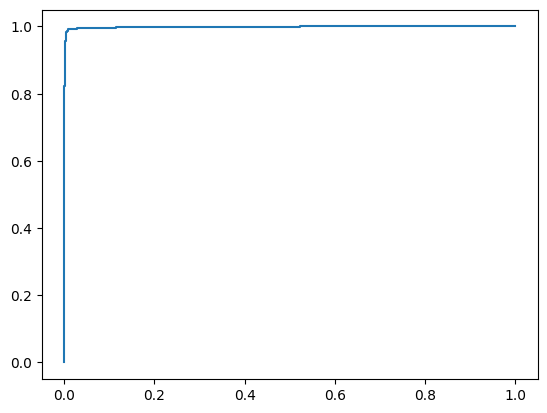

In [ ]:
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})')

In [ ]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import nltk
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
# Load the dataset
news_dataset = pd.read_csv('/content/sample_data/train.csv')
# Handling missing values
news_dataset.fillna('', inplace=True)
# Merging author name and news title
news_dataset['content'] = news_dataset['author'] + ' ' + news_dataset['title']
# Separating features and labels
X = news_dataset['content']
Y = news_dataset['label']
# Lemmatization
lemmatizer = WordNetLemmatizer()
def preprocess_text(content):
    # Remove URLs and special characters
    content = re.sub(r'http\S+|www\S+|https\S+', '', content, flags=re.MULTILINE)
    content = re.sub(r'@\w+', '', content)  # Remove mentions
    content = re.sub('[^a-zA-Z]', ' ', content)  # Remove special characters
    content = content.lower().split()
    content = [lemmatizer.lemmatize(word) for word in content if word not in stopwords.words('english')]
    return ' '.join(content)
news_dataset['content'] = news_dataset['content'].apply(preprocess_text)
# Converting textual data to numerical data
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(news_dataset['content'])
# Splitting training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)
# Logistic Regression model with hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  # Regularization strength
    'max_iter': [100, 200, 300]
}

log_model = LogisticRegression(solver='liblinear')
grid_search = GridSearchCV(log_model, param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, Y_train)
# Best model
best_log_model = grid_search.best_estimator_
# Model Accuracy
X_train_prediction = best_log_model.predict(X_train)
y_prob_log_reg = best_log_model.predict_proba(X_test)[:, 1]
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy of Training data : ', training_data_accuracy)
# Accuracy score on the testing data
X_test_prediction = best_log_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy of Test data : ', test_data_accuracy)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
precision = precision_score(X_test_prediction,Y_test)
print("Precision:", precision)
recall = recall_score(X_test_prediction,Y_test)
print("Recall (Sensitivity):", recall)
f1 = f1_score(X_test_prediction,Y_test)
print("F1-Score:", f1)

fpr_log_reg, tpr_log_reg, _ = roc_curve(Y_test, y_prob_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Accuracy of Training data :  0.99921875
Accuracy of Test data :  0.990625
Precision: 0.9937590014402304
Recall (Sensitivity): 0.9875954198473282
F1-Score: 0.990667623833453


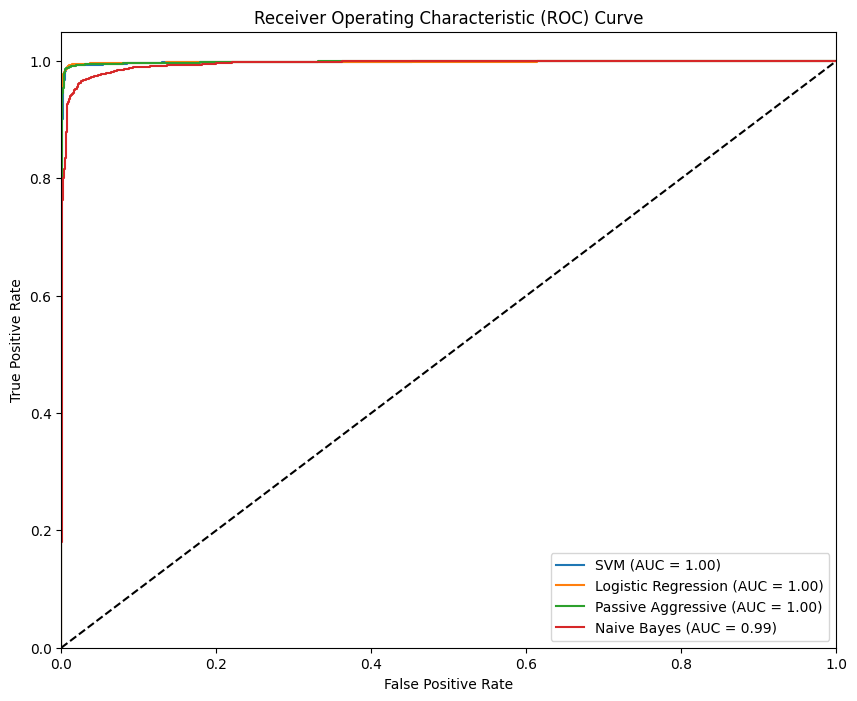

In [ ]:
# Plot ROC Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')
plt.plot(fpr_passive, tpr_passive, label=f'Passive Aggressive (AUC = {roc_auc_passive:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()